## FIShBOT sensitivity tests
When the interpolation was initiated, FIShBOT creates aggregated bottom products using a depth bin of 20 m. Here, we chose to use a 10 m depth bin to define "bottom". This creates a mismatch in the definitions of the bottom depth bin for the data used to create the bottom climatologies. Linus Stoltz (CFRF), the data manager for FIShBOT created a 10 m filter for using FIShBOT data. Here, we will conduct a sensitivity test to see the differences between the 20 m (native) FIShBOT depth bin and the special 10 m depth bin. It is preferable to use the original product if possible as it is citable and used in the scientific community. 

**BLUF:** After the sensitivity test, we are able to confidently use the original FIShBOT, with some of the cells with large differences between the 10 and 20 m versions removed. 

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import cartopy
import matplotlib.pyplot as plt
import calendar

The raw datasets used for the comparisons between the two datasets are not available here. The true FIShBOT dataset (ie aggregated using a 20 m depth filter) is available [HERE](https://erddap.ondeckdata.com/erddap/tabledap/fishbot_realtime.html). The specific dataset used for the comparisons is from 9/3/2026 and is archived on [Zenodo](https://zenodo.org/communities/fishbot/records?q=&l=list&p=1&s=10&sort=newest). The "FIShBOT" product using the 10 m depth filter was created specifically for this comparison and is not available here. <br>
The two datasets were merged on ```'time','grid_id',and 'stat_area'``` using an inner merge. The differences between the two datasets in temperature and salinity is read in below and used for the sensitivity analysis.

In [10]:
df = pd.read_csv('https://raw.githubusercontent.com/hsynan/READ-EDAB-Synan_hydrographic_climatologies/refs/heads/main/data/FIShBOT_20m-10m_diffs.csv')

Text(0.5, 0.98, 'Temperature differences between Fishbots with 20m and 10m depth bins')

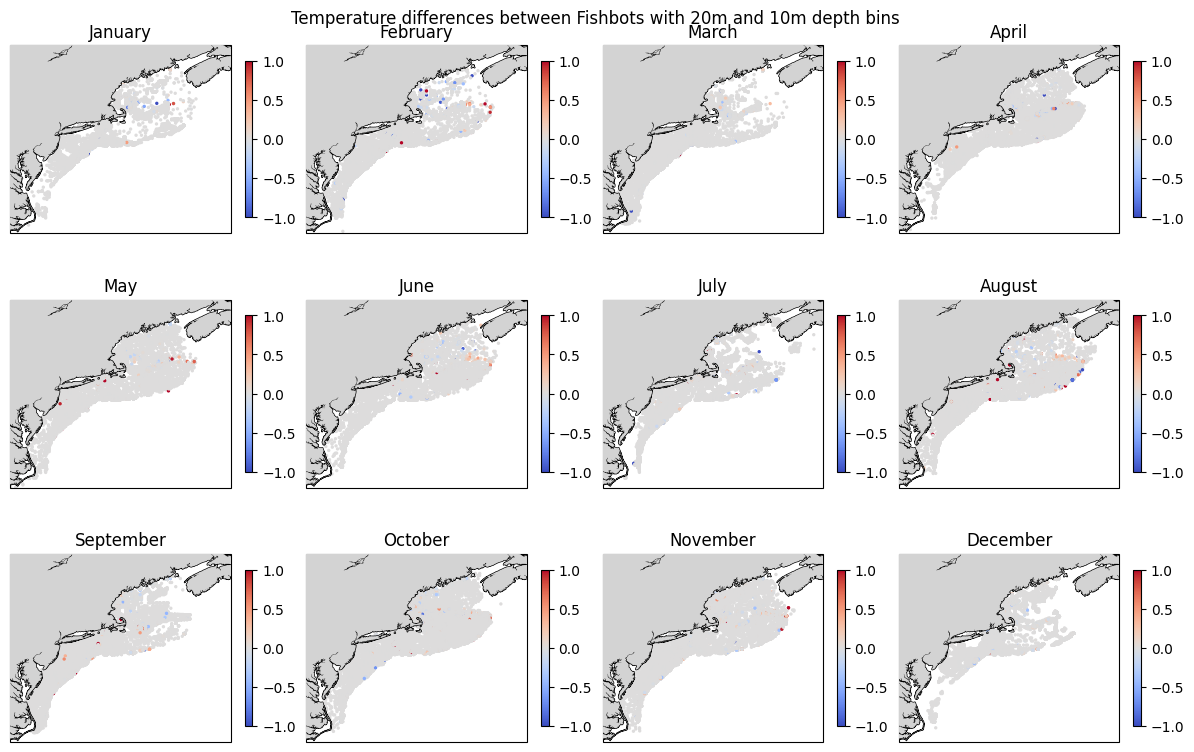

In [39]:
#plot monthly temp differences between fishbots
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 8),subplot_kw={'projection': cartopy.crs.PlateCarree()})
axes_flat = axes.flatten()
for x, ax in enumerate(axes_flat):
    sub=df[df.month==x+1]
    im=ax.scatter(sub.longitude_x.astype(float),sub.latitude_x.astype(float),c=sub.temp_diff,s=2,vmin=-1,vmax=1, cmap='coolwarm')
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #add land mask 
    ax.set_extent([-77, -63.5, 34.5, 46])
    plt.colorbar(im,ax=ax,shrink=0.6)
    ax.set_title(calendar.month_name[x+1])
plt.tight_layout()
plt.suptitle('Temperature differences between Fishbots with 20m and 10m depth bins')

Text(0.5, 0.98, 'Salinity differences between Fishbots with 20m and 10m depth bins')

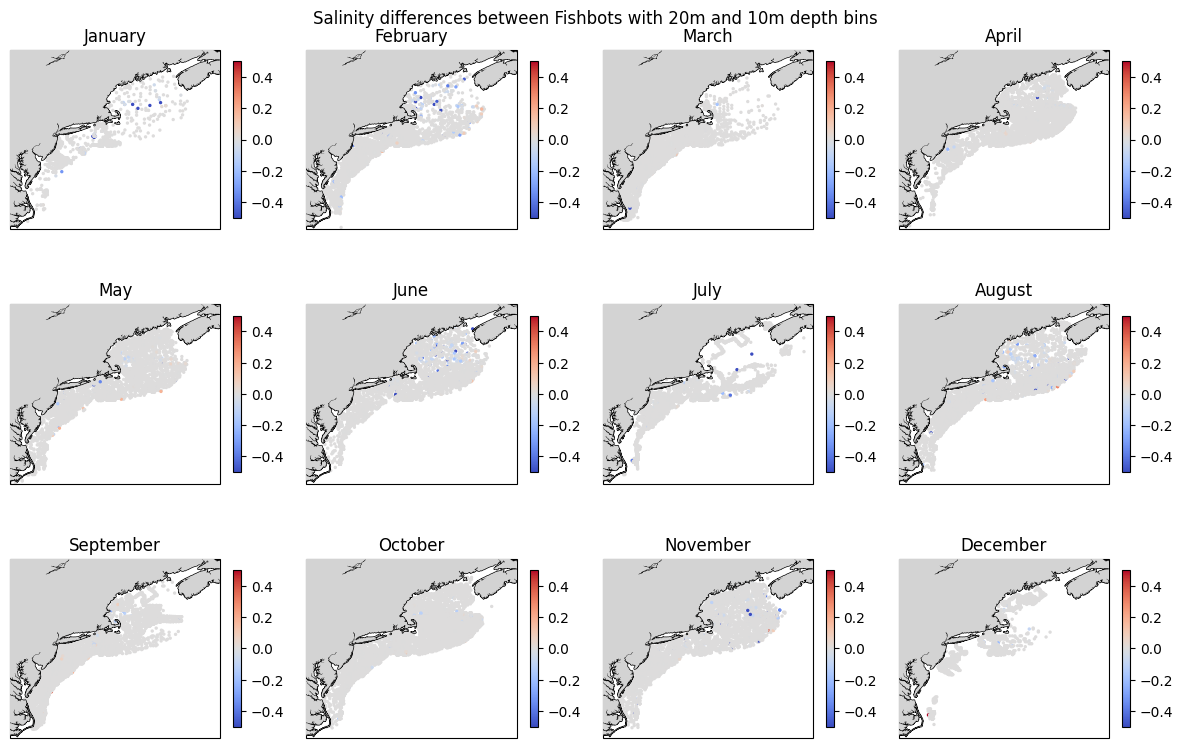

In [15]:
#plot monthly sal differences between Fishbots
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 8),subplot_kw={'projection': cartopy.crs.PlateCarree()})
axes_flat = axes.flatten()
for x, ax in enumerate(axes_flat):
    sub=df[df.month==x+1]
    im=ax.scatter(sub.longitude_x.astype(float),sub.latitude_x.astype(float),c=sub.sal_diff,s=2,vmin=-0.5,vmax=0.5, cmap='coolwarm')
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #add land mask 
    ax.set_extent([-77, -63.5, 34.5, 46])
    plt.colorbar(im,ax=ax,shrink=0.6)
    ax.set_title(calendar.month_name[x+1])
plt.tight_layout()
plt.suptitle('Salinity differences between Fishbots with 20m and 10m depth bins')

There are very few differences between the Original (20m) FIShBOT and the 10m version. 

In [34]:
subs = df.sal_diff
subs=subs[~np.isnan(subs)]
sub=df[df.temp_diff!=0]
print(f'{round(len(df[df.temp_diff!=0])/len(df)*100,3)}% (ie {len(sub)} observations) of the dataset has difference in temperature')
print(f'{round(len(subs[subs!=0])/len(subs)*100,3)}% (ie {len(subs[subs!=0])} observations) of the dataset has difference in salinity')
print(f'The max temperature difference is {max(sub.temp_diff,key=abs)}')
print(f'The min temperature (non 0) difference is {round(min(sub.temp_diff,key=abs),10)}')
print(f'The avg temperature difference is {abs(df.temp_diff).mean()}')
print(f'The max salinity difference is {np.nanmax(np.abs(subs))}')
print(f'The min salinity (non 0) difference is {np.nanmin(np.abs(subs[subs!=0]))}')
print(f'The avg salinity difference is {abs(subs.mean())}')

3.623% (ie 6480 observations) of the dataset has difference in temperature
5.159% (ie 2915 observations) of the dataset has difference in salinity
The max temperature difference is 7.445
The min temperature (non 0) difference is -0.001
The avg temperature difference is 0.0045881343137528985
The max salinity difference is 3.228000000000001
The min salinity (non 0) difference is 0.0009999999999976
The avg salinity difference is 0.0018381559154057143


Text(0.5, 1.0, 'Histogram of temperature differences between\nFishbot (20m depth bin) and Fishbot (10m depth bin)')

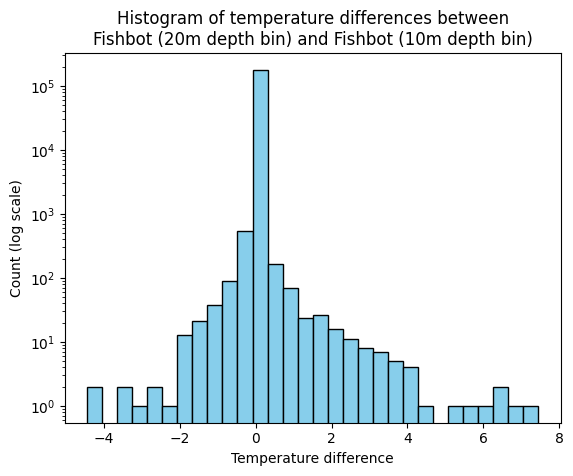

In [35]:
#plot histograms of residual distribution -- temp
#histogram
plt.hist(df.temp_diff, bins=30,log=True, color='skyblue', edgecolor='black')
plt.xlabel('Temperature difference')
plt.ylabel('Count (log scale)')
plt.title('Histogram of temperature differences between\nFishbot (20m depth bin) and Fishbot (10m depth bin)')

Text(0.5, 1.0, 'Histogram of salinity differences between\nFishbot (20m depth bin) and Fishbot (10m depth bin)')

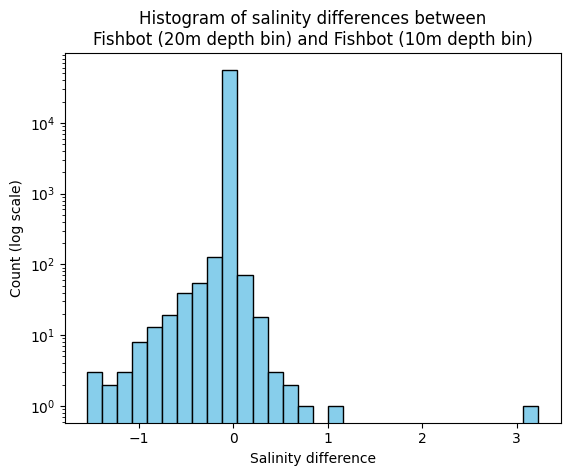

In [36]:
## Histogram of residual distribution -- sal
plt.hist(df.sal_diff, bins=30,log=True, color='skyblue', edgecolor='black')
plt.xlabel('Salinity difference')
plt.ylabel('Count (log scale)')
plt.title('Histogram of salinity differences between\nFishbot (20m depth bin) and Fishbot (10m depth bin)')

In [37]:
print(f'Difference threshold of 0.5 C: results in {len(df[(abs(df.temp_diff)>0.5)])} data points to remove')
print(f'Difference threshold of 1 C: results in {len(df[(abs(df.temp_diff)>1)])} data points to remove')
print(f'Difference threshold of 2 C: results in {len(df[(abs(df.temp_diff)>2)])} data points to remove')
print(f'Difference threshold of 3 C: results in {len(df[(abs(df.temp_diff)>3)])} data points to remove')
print(f'Difference threshold of 4 C: results in {len(df[(abs(df.temp_diff)>4)])} data points to remove')

Difference threshold of 0.5 C: results in 407 data points to remove
Difference threshold of 1 C: results in 185 data points to remove
Difference threshold of 2 C: results in 63 data points to remove
Difference threshold of 3 C: results in 30 data points to remove
Difference threshold of 4 C: results in 13 data points to remove


In [38]:
print(f'Difference threshold of 0.1: results in {len(df[(abs(df.sal_diff)>0.1)])} data points to remove')
print(f'Difference threshold of 0.5: results in {len(df[(abs(df.sal_diff)>0.5)])} data points to remove')
print(f'Difference threshold of 0.7: results in {len(df[(abs(df.sal_diff)>0.7)])} data points to remove')
print(f'Difference threshold of 1: results in {len(df[(abs(df.sal_diff)>1)])} data points to remove')
print(f'Difference threshold of 2: results in {len(df[(abs(df.sal_diff)>2)])} data points to remove')

Difference threshold of 0.1: results in 348 data points to remove
Difference threshold of 0.5: results in 74 data points to remove
Difference threshold of 0.7: results in 35 data points to remove
Difference threshold of 1: results in 12 data points to remove
Difference threshold of 2: results in 1 data points to remove


We can now confidently use the true FIShBOT product, but removing some of the outliers (cells with large differences between the original 20 m FIShBOT and the 10m version). We will remove observations with more than 2 degrees C and 0.5 PSU difference. The ```df_dropped``` will be the input that will be concatenated with other sources and become the data used to create the interpolation.

In [ ]:
df_dropped = df.drop(index=list(df[(abs(df.temp_diff)>2) | (abs(df.sal_diff)>0.5)].index)) #find rows and ditch em 
#then the idea is to use this for the interpolation.... does that make sense? 
df_dropped.to_csv(r'W:\nadata\PROJECTS\NESCAPES\SOURCE_DATA\FISHBOT\fishbot_083126_OG20m_filtered.csv')